# 介面隔離原則 (Interface Segregation Principle, ISP)



## 定義
類別不應該被強迫依賴它不使用的方法。應將大型接口拆分為更小、更專注的接口。

- 原始實作類別圖（無ISP）:

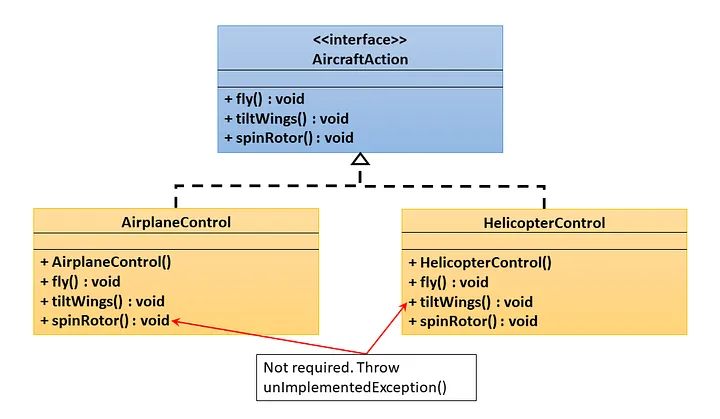

- 更新實現的類別圖（與ISP）:

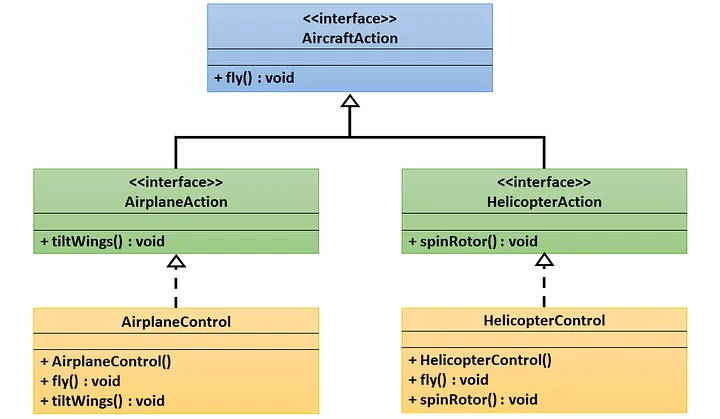

## [ref](https://hyperionnkj.medium.com/software-engineering-principle-interface-segregation-principle-isp-10a5a33d6683)

## 判斷導入時機

- Do：
當接口包含過多方法，導致類別需要實現許多不相關的功能。
當不同客戶端有不同的功能需求時，應避免它們依賴於同一個大而全的接口。

- Don't：
當接口的拆分會導致不必要的代碼膨脹，增加維護成本時。


多個給客戶專用的介面，優於一個通用需求介面
在ISP原則下，interface裡面有多個方法的話，應該拆成多個介面，每個介面就只有一點點的方法，只用有用到的介面，沒用到的方法不要繼承，免得用錯
介面不要太大，剛好就好
使用interface可以容易達到鬆散耦合、容易安全重構、容易功能擴充


當介面需要分割時，或當類別使用的時機也可以被分割時
例如一個類別有十幾個方法，你繼承他是因為要用到某一個，那就把那個方法切成介面，你的新類別跟就類別就可以透過介面相依，達到鬆散耦合，就只個一個方法有關聯

----


## 完整案例

### 需求情境

一個工作環境中包含兩類員工：

人類員工 (HumanWorker)：能工作並需要吃飯。
機器人員工 (RobotWorker)：只能工作，不需要吃飯。

### 初始設計


In [8]:
class Worker:
    def work(self):
        pass

    def eat(self):
        pass

class HumanWorker(Worker):
    def work(self):
        print("Working")

    def eat(self):
        print("Eating lunch")

class RobotWorker(Worker):
    def work(self):
        print("Working")

    def eat(self):
        raise NotImplementedError("Robots don't eat")


> 問題分析

- 違反 ISP：

RobotWorker 被迫依賴於不相關的 eat() 方法，增加了實現的冗餘和潛在錯誤。

- 低可維護性：

如果 Worker 接口新增其他與機器人無關的方法，會進一步擴大影響範圍。

- 不必要的依賴：

每個類別應只關注自己的職責，而不是適配所有功能。

### 重構設計
解決方案: 將 Worker 接口拆分為更小的接口，分別處理工作 (Workable) 和進食 (Eatable) 職責。


In [9]:
# 定義更小的接口
class Workable:
    def work(self):
        pass

class Eatable:
    def eat(self):
        pass

# 人類員工實現兩個接口
class HumanWorker(Workable, Eatable):
    def work(self):
        print("Working")

    def eat(self):
        print("Eating lunch")

# 機器人員工僅實現工作接口
class RobotWorker(Workable):
    def work(self):
        print("Working")


In [10]:
# 測試模擬
def simulate_employee(employee):
    employee.work()
    if isinstance(employee, Eatable):
        employee.eat()

# 人類員工
human = HumanWorker()
simulate_employee(human)

# 機器人員工
robot = RobotWorker()
simulate_employee(robot)


Working
Eating lunch
Working


### 重構思考要點

1. 職責分離：
- Workable 僅處理工作相關邏輯。
- Eatable 僅處理進食相關邏輯。
2. 靈活性提升：人類員工實現兩個接口，機器人員工只需要實現與其相關的接口。
3. 可維護性提高：未來如果需要新增功能，只需擴展接口或創建新接口，而不影響已有類別。

### 擴展設計
如果未來需要支持另一類型的員工，例如 遠程人員 (RemoteWorker)，只需實現 Workable 接口即可，無需修改現有代碼。

In [11]:
class RemoteWorker(Workable):
    def work(self):
        print("Working remotely")


remote = RemoteWorker()
simulate_employee(remote)


Working remotely


### 重構優點

- 滿足 ISP：
每個類別僅依賴於與其相關的接口。

- 靈活性：
可以根據不同需求創建新的接口，而不影響現有系統。

- 可擴展性：
未來新增員工類型時，只需實現對應的接口，不會導致代碼膨脹。

適用場景
- 複雜系統中多角色設計：如員工管理、設備管理等，需根據角色職責進行精確功能分離。
- 功能需求多樣化：不同模組或類別的需求差異較大。


總結設計脈絡

- SRP：聚焦單一職責，提升代碼可讀性和可測試性。
- OCP：通過抽象實現擴展，避免直接修改已有代碼。
- LSP：確保子類行為與父類一致，增強多態性。
- DIP：引入抽象分離高層業務邏輯與低層技術細節。
- ISP：按需拆分接口，減少不相關功能的耦合。